## Milestone 2: Vectorization, Floating Point Errors, and Numerical Reliability

## 1. Introduction to Numerical Reliability
---
Scientific computing relies on continuous mathematics mapped onto discrete computer hardware. Because computers represent real numbers in base-2 (binary) memory, certain base-10 decimals cannot be represented exactly, leading to floating-point truncation. Furthermore, as we process large agricultural datasets over long simulation periods, computational speed (vectorization) and stability (error propagation) become just as critical as the underlying algebra.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import os

# Suppress scientific notation for cleaner output
np.set_printoptions(suppress=True)

# Load the weather data
base_path = "../data/raw"
weather_df = pd.read_csv(os.path.join(base_path, "weather_daily.csv"), na_values=['NA', ''])

# Forward fill missing values to ensure arrays have continuous data for performance testing
weather_df.ffill(inplace=True)

,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62.0,1.62,0.71
2,2026-03-03,3.0,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61.0,1.36,0.62
5,2026-03-06,0.0,26.7,66.8,3.07,0.49
6,2026-03-07,1.3,24.9,61.2,1.83,0.72
7,2026-03-08,1.3,24.9,69.6,3.10,0.65
8,2026-03-09,0.0,23.6,64.0,2.12,0.72
9,2026-03-10,18.4,22.5,74.4,2.62,0.76


## 2. Floating Point Arithmetic and Representation Error

To demonstrate why numerical reliability matters, we first look at standard floating-point representation (IEEE 754 standard).

In [2]:
# Demonstrating the classic 0.1 + 0.2 floating point anomaly
val1 = 0.1
val2 = 0.2
expected = 0.3
actual = val1 + val2

print(f"0.1 + 0.2 = {actual}")
print(f"Is {val1} + {val2} exactly equal to {expected}? : {actual == expected}")

# Demonstrating safe floating point comparison using NumPy's isclose
is_safe = np.isclose(actual, expected)
print(f"Using np.isclose() for scientific comparison: {is_safe}")

0.1 + 0.2 = 0.30000000000000004
Is 0.1 + 0.2 exactly equal to 0.3? : False
Using np.isclose() for scientific comparison: True


### Interpretation of Floating Point Errors

**Scientific Interpretation**: The calculation $0.1 + 0.2$ results in $0.30000000000000004$ rather than exactly $0.3$. This occurs because fractions like $1/10$ and $1/5$ result in infinitely repeating fractions in binary. If we design our irrigation triggers using exact equality operators ($==$) on floating-point sensor data, our smart irrigation system might fail to activate. Therefore, numerical reliability demands we use tolerance-based comparisons (like np.isclose) for all floating-point logic.

## Vectorization vs. Loops
---
### 3. Performance: Python Loops vs. NumPy Vectorization
As our dataset grows (e.g., scaling from a single farm to all of Kiambu County), iterating through data row-by-row becomes a bottleneck. We compare a standard Python for loop against NumPy's C-compiled vectorized operations using our Evapotranspiration (ET) model.$$ET = \max(0, 0.12T + 0.35W + 2.4Solar - 0.025H)$$

In [3]:
# Extract data as Python lists and NumPy arrays
t_list = weather_df['temperature_c'].tolist()
w_list = weather_df['wind_speed_mps'].tolist()
s_list = weather_df['solar_index'].tolist()
h_list = weather_df['humidity_pct'].tolist()

t_arr = weather_df['temperature_c'].values
w_arr = weather_df['wind_speed_mps'].values
s_arr = weather_df['solar_index'].values
h_arr = weather_df['humidity_pct'].values

# 1. Standard Python Loop Approach
def et_loop(t, w, s, h):
    et_results = []
    for i in range(len(t)):
        et = (0.12 * t[i]) + (0.35 * w[i]) + (2.4 * s[i]) - (0.025 * h[i])
        et_results.append(max(0, et))
    return et_results

# 2. NumPy Vectorized Approach
def et_vectorized(t, w, s, h):
    et = (0.12 * t) + (0.35 * w) + (2.4 * s) - (0.025 * h)
    return np.maximum(0, et)

# Artificially expand dataset to 300,000 rows to simulate large-scale processing
t_large, w_large, s_large, h_large = t_list * 10000, w_list * 10000, s_list * 10000, h_list * 10000
ta_large, wa_large, sa_large, ha_large = np.array(t_large), np.array(w_large), np.array(s_large), np.array(h_large)

# Benchmark Loop
start_loop = time.time()
loop_res = et_loop(t_large, w_large, s_large, h_large)
end_loop = time.time()
loop_time = end_loop - start_loop

# Benchmark Vectorization
start_vec = time.time()
vec_res = et_vectorized(ta_large, wa_large, sa_large, ha_large)
end_vec = time.time()
vec_time = end_vec - start_vec

print(f"--- Performance Benchmark (300,000 records) ---")
print(f"Python Loop Time:  {loop_time:.6f} seconds")
print(f"NumPy Vector Time: {vec_time:.6f} seconds")
print(f"Speedup Factor:    {loop_time / vec_time:.2f}x faster")

--- Performance Benchmark (300,000 records) ---
Python Loop Time:  0.140630 seconds
NumPy Vector Time: 0.014382 seconds
Speedup Factor:    9.78x faster


## Error Propagation
---
### 4. Error Propagation in Irrigation ModelsSensors in the field are rarely perfectly accurate.
 A temperature sensor might have a generic $\pm 1.5^\circ C$ noise margin. If we input noisy data into our Evapotranspiration model, the error propagates, ultimately altering the amount of water the system recommends.

Cumulative Irrigation Volume Error over 30 days: 3.94 mm


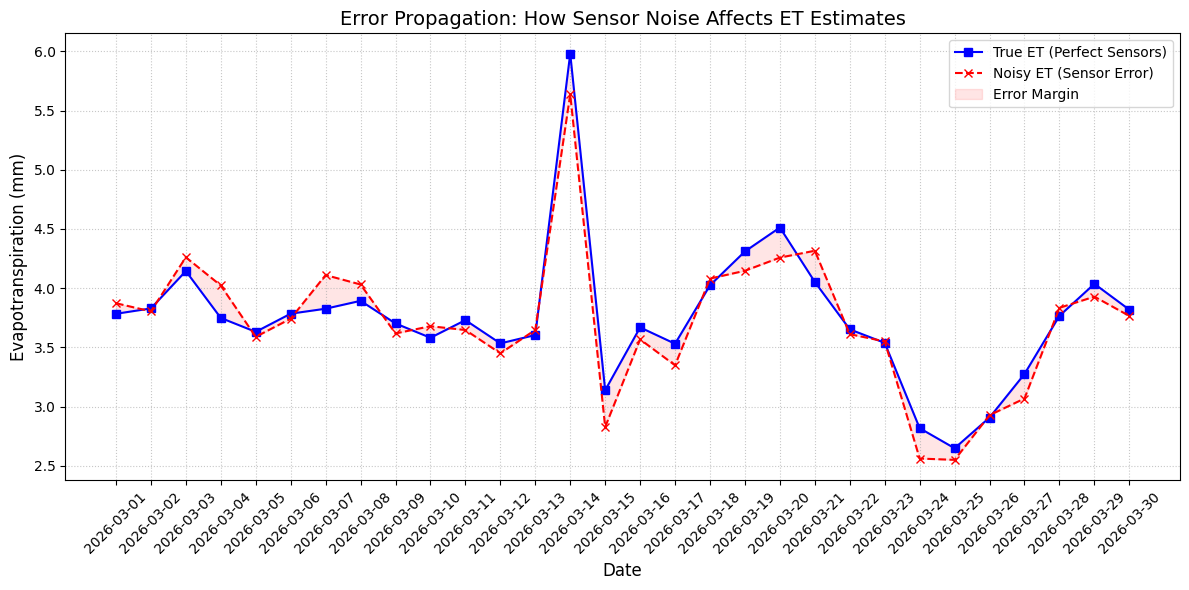

In [4]:
# Calculate exact baseline ET (assuming perfect sensors)
baseline_et = et_vectorized(t_arr, w_arr, s_arr, h_arr)

# Introduce normally distributed measurement noise to temperature (Mean=0, StdDev=1.5 degrees)
np.random.seed(42) 
temperature_noise = np.random.normal(0, 1.5, len(t_arr))
noisy_t_arr = t_arr + temperature_noise

# Calculate affected ET
noisy_et = et_vectorized(noisy_t_arr, w_arr, s_arr, h_arr)

# Calculate the propagation of error (Absolute and Percentage)
absolute_error = np.abs(noisy_et - baseline_et)
cumulative_irrigation_error = np.sum(absolute_error)

print(f"Cumulative Irrigation Volume Error over 30 days: {cumulative_irrigation_error:.2f} mm")

# Plot the Error Propagation
plt.figure(figsize=(12, 6))
plt.plot(weather_df['date'], baseline_et, label='True ET (Perfect Sensors)', color='blue', marker='s')
plt.plot(weather_df['date'], noisy_et, label='Noisy ET (Sensor Error)', color='red', linestyle='--', marker='x')
plt.fill_between(weather_df['date'], baseline_et, noisy_et, color='red', alpha=0.1, label='Error Margin')

plt.title('Error Propagation: How Sensor Noise Affects ET Estimates', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Evapotranspiration (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

 ## Conclusion
 ---
 ### 5. Conclusion on Numerical Reliability
 As demonstrated, minor hardware noise ($\pm 1.5^\circ C$) propagated through our linear ET equation to generate a cumulative miscalculation of irrigation requirements. Over a 10-hectare farm, a few millimeters of propagated error translates to thousands of liters of wasted water or dangerous crop stress. Therefore, our optimization models in Level 5 must account for these margins of uncertainty.